In [1]:
from features_definition import FEATURES
import plotly.express as px

2025-12-09 21:57:26 - INFO - Fetching Page 1...
2025-12-09 21:57:26 - INFO - GET https://api.gridstatus.io/v1/datasets/ercot_spp_day_ahead_hourly/query
2025-12-09 21:57:26 - INFO - Params: {'start_time': Timestamp('2020-01-01 00:00:00'), 'end_time': Timestamp('2025-11-01 00:00:00'), 'publish_time_start': None, 'publish_time_end': None, 'limit': None, 'page': 1, 'page_size': None, 'resample_frequency': None, 'resample_by': None, 'resample_function': None, 'publish_time': None, 'timezone': 'US/Central', 'cursor': '', 'filter_column': 'location', 'filter_value': 'LZ_HOUSTON', 'filter_operator': '=', 'return_format': 'json', 'json_schema': 'array-of-arrays'}
2025-12-09 21:57:44 - INFO - Done in 17.96 seconds. 
2025-12-09 21:57:44 - INFO - Fetching Page 2...
2025-12-09 21:57:44 - INFO - GET https://api.gridstatus.io/v1/datasets/ercot_spp_day_ahead_hourly/query
2025-12-09 21:57:44 - INFO - Params: {'start_time': Timestamp('2020-01-01 00:00:00'), 'end_time': Timestamp('2025-11-01 00:00:00'), 

In [2]:
df = FEATURES
df.head()

,time,location,location_type,market,interval_start_local,interval_start_utc,interval_end_local,interval_end_utc,spp,heating_degrees,...,EER_EPMRR_PF4_Y05LA_DPG,EER_EPMRU_PF4_RGC_DPG,EER_EPMRU_PF4_Y35NY_DPG,RBRTE,RNGC1,RNGC2,RNGC3,RNGC4,RNGWHHD,RWTC
0,2020-01-01 00:00:00-06:00,LZ_HOUSTON,Load Zone,DAY_AHEAD_HOURLY,2020-01-01 11:30:00-06:00,2020-01-01 17:30:00+00:00,2020-01-01 12:30:00-06:00,2020-01-01 18:30:00+00:00,12.722083,35.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-02 00:00:00-06:00,LZ_HOUSTON,Load Zone,DAY_AHEAD_HOURLY,2020-01-02 11:30:00-06:00,2020-01-02 17:30:00+00:00,2020-01-02 12:30:00-06:00,2020-01-02 18:30:00+00:00,15.305000,31.4,...,NaN,NaN,NaN,67.05,2.122,2.093,2.098,2.142,2.05,NaN
2,2020-01-03 00:00:00-06:00,LZ_HOUSTON,Load Zone,DAY_AHEAD_HOURLY,2020-01-03 11:30:00-06:00,2020-01-03 17:30:00+00:00,2020-01-03 12:30:00-06:00,2020-01-03 18:30:00+00:00,16.529167,29.2,...,1.789,NaN,NaN,NaN,NaN,2.112,2.113,2.156,2.06,NaN
3,2020-01-04 00:00:00-06:00,LZ_HOUSTON,Load Zone,DAY_AHEAD_HOURLY,2020-01-04 11:30:00-06:00,2020-01-04 17:30:00+00:00,2020-01-04 12:30:00-06:00,2020-01-04 18:30:00+00:00,17.431250,29.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-05 00:00:00-06:00,LZ_HOUSTON,Load Zone,DAY_AHEAD_HOURLY,2020-01-05 11:30:00-06:00,2020-01-05 17:30:00+00:00,2020-01-05 12:30:00-06:00,2020-01-05 18:30:00+00:00,15.212500,30.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
FEATURES.columns.tolist()

['time',
 'location',
 'location_type',
 'market',
 'interval_start_local',
 'interval_start_utc',
 'interval_end_local',
 'interval_end_utc',
 'spp',
 'heating_degrees',
 'cooling_degrees',
 'dew_point_simple',
 'sunshine_fraction',
 'rain_flag',
 'wind_squared',
 'GS10',
 'T5YIE',
 'EER_EPD2DC_PF4_Y05LA_DPG',
 'EER_EPD2DXL0_PF4_RGC_DPG',
 'EER_EPD2DXL0_PF4_Y35NY_DPG',
 'EER_EPD2F_PF4_Y35NY_DPG',
 'EER_EPJK_PF4_RGC_DPG',
 'EER_EPLLPA_PF4_Y44MB_DPG',
 'EER_EPMRR_PF4_Y05LA_DPG',
 'EER_EPMRU_PF4_RGC_DPG',
 'EER_EPMRU_PF4_Y35NY_DPG',
 'RBRTE',
 'RNGC1',
 'RNGC2',
 'RNGC3',
 'RNGC4',
 'RNGWHHD',
 'RWTC']

- time: US/Central
- location / location_type: LZ_HOUSTON
- market: DAY_AHEAD_HOURLY
- spp: Settlement Point Price
- GS10: The yield on 10-year US Treasuries
- T5YIE: Five-year inflation expectations (break-even inflation)
- RBRTE: Brent crude oil spot price
- RWTC: West Texas Intermediate spot ptice (USD/bbl)
- RNGC1~RNGC4: natural gas the first to the fourth month, from NYMEX (USD/MMBtu)
- RNGWHHD: Henry Hub natural gas spot price
- EER_...: petroleum prices

In [4]:
cols = ['spp',
       'heating_degrees', 'cooling_degrees', 'dew_point_simple',
       'sunshine_fraction', 'rain_flag', 'wind_squared', 'GS10', 'T5YIE', 'EER_EPD2DC_PF4_Y05LA_DPG',
       'EER_EPD2DXL0_PF4_RGC_DPG', 'EER_EPD2DXL0_PF4_Y35NY_DPG',
       'EER_EPD2F_PF4_Y35NY_DPG', 'EER_EPJK_PF4_RGC_DPG',
       'EER_EPLLPA_PF4_Y44MB_DPG', 'EER_EPMRR_PF4_Y05LA_DPG',
       'EER_EPMRU_PF4_RGC_DPG', 'EER_EPMRU_PF4_Y35NY_DPG', 'RBRTE', 'RNGWHHD',
       'RWTC']

df[cols] = df[cols].astype(float)
fig = px.line(df, x='time', y=cols, title='variables')
fig.show()

In [5]:
fig = px.imshow(df[cols].corr())
fig.show()

# Cleaning data

In [6]:
import pandas as pd

## deal with missing value

In [7]:
df1=df.copy()
df1 = df1.sort_values('time').drop_duplicates(subset=['time'], keep='first')

In [8]:
summary = pd.DataFrame({
    "dtype": df1.dtypes.astype(str),
    "non_null": df1.notna().sum(),
    "nulls": df1.isna().sum(),
    "null_%": (df1.isna().mean()*100).round(2),
    "n_unique": df1.nunique(dropna=True),
})
summary.sort_values("null_%", ascending=False)

,dtype,non_null,nulls,null_%,n_unique
EER_EPMRU_PF4_Y35NY_DPG,float64,338,1793,84.14,306
EER_EPJK_PF4_RGC_DPG,float64,362,1769,83.01,339
EER_EPMRR_PF4_Y05LA_DPG,float64,373,1758,82.50,341
EER_EPMRU_PF4_RGC_DPG,float64,387,1744,81.84,341
EER_EPLLPA_PF4_Y44MB_DPG,float64,389,1742,81.75,274
EER_EPD2F_PF4_Y35NY_DPG,float64,484,1647,77.29,437
EER_EPD2DXL0_PF4_RGC_DPG,float64,489,1642,77.05,438
EER_EPD2DC_PF4_Y05LA_DPG,float64,534,1597,74.94,463
RBRTE,float64,539,1592,74.71,515
EER_EPD2DXL0_PF4_Y35NY_DPG,float64,543,1588,74.52,488


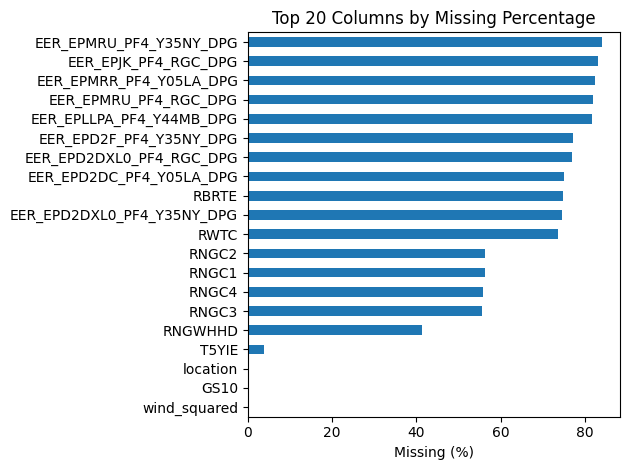

In [9]:
import matplotlib.pyplot as plt

plot_data = summary["null_%"].sort_values(ascending=False).head(20)
plt.figure()
plot_data.plot.barh()
plt.gca().invert_yaxis()
plt.xlabel("Missing (%)")
plt.title("Top 20 Columns by Missing Percentage")
plt.tight_layout()

### take average for all petroleum price

In [11]:
cols_petro = [
    'EER_EPD2F_PF4_Y35NY_DPG','EER_EPMRR_PF4_Y05LA_DPG','EER_EPJK_PF4_RGC_DPG',
    'EER_EPMRU_PF4_RGC_DPG','EER_EPD2DXL0_PF4_Y35NY_DPG','RBRTE',
    'EER_EPMRU_PF4_Y35NY_DPG','RWTC','EER_EPD2DXL0_PF4_RGC_DPG',
    'EER_EPD2DC_PF4_Y05LA_DPG','EER_EPLLPA_PF4_Y44MB_DPG'
]
df2 = df1.copy()
df2[cols_petro] =df1[cols_petro].apply(pd.to_numeric, errors='coerce')
df2['eer_bucket_row_mean'] = df2[cols_petro].mean(axis=1, skipna=True)

### take average for all gas future price

In [12]:
cols_gas = ['RNGC1','RNGC2','RNGC3','RNGC4']
df3 = df2.copy()
df3[cols_gas] =df2[cols_gas].apply(pd.to_numeric, errors='coerce')
df3['gas_future_mean'] = df3[cols_gas].mean(axis=1, skipna=True)

In [25]:
df_new = df3[[
    'time', 'spp',
    'heating_degrees',
    'cooling_degrees',
    'dew_point_simple',
    'sunshine_fraction', 
    'rain_flag',
    'wind_squared',
    'GS10',
    'T5YIE',
    'RNGWHHD',
    'RWTC',
    'eer_bucket_row_mean',
    'gas_future_mean'
    ]]

In [26]:
df_new.isna().sum()

time                      0
spp                       0
heating_degrees           0
cooling_degrees           0
dew_point_simple          0
sunshine_fraction         0
rain_flag                 0
wind_squared              0
GS10                      0
T5YIE                    83
RNGWHHD                 881
RWTC                   1569
eer_bucket_row_mean     682
gas_future_mean        1062
dtype: int64

Columns `T5YIE`, `RNGWHHD`, `RWTC`, `gas_future_mean` contain missing values because it indicates non-trading days (e.g., weekend, holidays). We use forward & backward fill to handle them.

`eer_bucket_row_mean` varies daily and may have missing days where data was not published. We use linear interpolation to deal with missingness.

In [27]:
cols_fill_na = ['T5YIE', 'RNGWHHD', 'RWTC', 'gas_future_mean']
for col in cols_fill_na:
    df_new[col] = df_new[col].ffill().bfill()

df_new['eer_bucket_row_mean'] = df_new['eer_bucket_row_mean'].interpolate(methos = 'linear').ffill().bfill()

df_new.isna().sum()

/var/folders/9y/qvp8dhrs4vj2jgkx091k1tzw0000gn/T/ipykernel_21564/1547823051.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/9y/qvp8dhrs4vj2jgkx091k1tzw0000gn/T/ipykernel_21564/1547823051.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



time                   0
spp                    0
heating_degrees        0
cooling_degrees        0
dew_point_simple       0
sunshine_fraction      0
rain_flag              0
wind_squared           0
GS10                   0
T5YIE                  0
RNGWHHD                0
RWTC                   0
eer_bucket_row_mean    0
gas_future_mean        0
dtype: int64

In [28]:
cols = ['spp',
        'heating_degrees',
        'cooling_degrees',
        'dew_point_simple',
        'sunshine_fraction',
        'rain_flag',
        'wind_squared',
        'GS10','T5YIE',
        'RNGWHHD',
        'RWTC',
        'eer_bucket_row_mean',
        'gas_future_mean'
        ]

df_new[cols] = df_new[cols].astype(float)
fig = px.line(df_new, x = 'time', y=cols, title = 'variables')
fig.show()

/var/folders/9y/qvp8dhrs4vj2jgkx091k1tzw0000gn/T/ipykernel_21564/289389073.py:15: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [30]:
corr = df_new[cols].corr()

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale="RdBu_r",
    title="Correlation Heatmap",
)

fig.update_layout(width=900, height=900)
fig.show()